# Notebook 09 — SAM 3 Box-Prompted Refinement (Zero-Shot Segmentation)

**Paper artifact:** the SAM 3 box-prompted segmentation row of the hybrid-pipeline evaluation (zero-shot pixel-level IoU / Dice of SAM 3 masks against the ground-truth corrosion masks).

This notebook is the **final validation stage** of the two-stage hybrid pipeline for underwater **corrosion** detection and segmentation. The best YOLO26 detector (Medium backbone, from the 3x3 generational benchmark) produces bounding boxes that are fed to **SAM 3** (`facebook/sam3`) as **box prompts**, in a fully **zero-shot** setting (SAM 3 is never fine-tuned on corrosion). The resulting masks are compared, pixel by pixel, against binary ground-truth masks over the held-out evaluation set, and consolidated into Mean IoU and Mean Dice.

**Key result.** Averaged over the full evaluation set (N = 191), the pipeline reaches **Mean IoU 0.7315** and **Mean Dice 0.7435**. See the integrity note in Section 6 on how this set-wide mean relates to the positives-only figure reported in the paper.

---

| | |
|---|---|
| **Inputs** | YOLO26 checkpoint `modelos_entrenados/yolo26m.pt`; `sam3_eval_dataset/` (191 images + 191 binary PNG masks, 640x640); SAM 3 weights `facebook/sam3` from the Hugging Face Hub |
| **Output** | `sam3_eval_results.csv` (per-image IoU/Dice/BCR) and `sam3_quantitative_analysis.png`; consolidated Mean IoU / Mean Dice |
| **Environment** | Transformers 5.13.0 (Sam3Model/Sam3Processor) · Ultralytics 8.4.5 · PyTorch 2.9.0+cu128 · NVIDIA RTX 4090 |

> **Note on outputs.** All code cells and their outputs are preserved exactly as executed on the original GPU run; Hugging Face download logs and the IOPub rate-limit notice appear in their original form. Re-running under the pinned environment reproduces the same metrics.

### Formal hypothesis

> The YOLO26 + SAM 3 pipeline produces corrosion segmentations whose **IoU is significantly greater than 0.5** on the unseen test set, indicating pixel-accurate spatial localization.

### Scientific-integrity note (held-out set)

> The evaluated images belong to the **locked test set** (held-out split) that was **strictly excluded from the K-Fold training** in the training notebook. The `ANTI-LEAKAGE ASSERTION PASSED` statement in that notebook certifies the absence of train/val/test contamination.

## 1 · Reproducibility and environment

We fix all global seeds (`SEED = 42`) across `random`, NumPy and PyTorch, enable deterministic cuDNN, and report the runtime (PyTorch version, device, working directory, GPU) to make the run fully reproducible.

In [1]:
# ==============================================================================
# CELL 1: REPRODUCIBILITY - global seeds and configuration
# ==============================================================================

import random
import warnings
import os
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm.notebook import tqdm

# -- Seeds ─────────────────────────────────────────────────────────────────
SEED: int = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if (torch.cuda.is_available() and torch.cuda.device_count() > 0):
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

warnings.filterwarnings('ignore')

DEVICE: str = "cuda" if (torch.cuda.is_available() and torch.cuda.device_count() > 0) else "cpu"

print("=" * 60)
print("  REPRODUCIBILITY GUARANTEED")
print("=" * 60)
print(f"  SEED      : {SEED}")
print(f"  PyTorch   : {torch.__version__}")
print(f"  Device     : {DEVICE}")
print(f"  CWD        : {os.getcwd()}")
if (torch.cuda.is_available() and torch.cuda.device_count() > 0):
    print(f"  GPU       : {torch.cuda.get_device_name(0)}")
print("=" * 60)

  REPRODUCIBILITY GUARANTEED
  SEED      : 42
  PyTorch   : 2.9.0+cu128
  Device     : cuda
  CWD        : /home/user/work/EONSEA/Articulo-Corrosion
  GPU       : NVIDIA GeForce RTX 4090


## 2 · Path and dataset configuration

We auto-detect the evaluation dataset (`sam3_eval_dataset/`, holding the images and their binary PNG ground-truth masks) and locate the trained YOLO26 checkpoint (`yolo26m.pt`) by probing several candidate locations. The console confirms **191 images and 191 PNG masks**.

In [2]:
# ==============================================================================
# CELL 2: PATHS - automatic detection of models and dataset
# ==============================================================================

def _find_eval_root() -> Path:
    """Locate sam3_eval_dataset by probing multiple candidate paths."""
    cwd = Path(os.getcwd())
    candidates = [
        cwd / "sam3_eval_dataset",
        cwd.parent / "sam3_eval_dataset",
        Path("/home/user/work/EONSEA/Articulo-Corrosion/sam3_eval_dataset"),
        Path("/home/user/work/Resultados_Paper_Final/sam3_eval_dataset"),
    ]
    for p in candidates:
        if p.exists() and (p / "images").exists(): return p
    search_roots = [cwd] + list(cwd.parents)[:4]
    for root in search_roots:
        for found in root.rglob("sam3_eval_dataset"):
            if (found / "images").exists(): return found
    raise FileNotFoundError("❌ Dataset not found. Upload and unzip 'sam3_eval_dataset.zip'.")

EVAL_ROOT      = _find_eval_root()
EVAL_IMGS_DIR  = EVAL_ROOT / "images"
EVAL_MASKS_DIR = EVAL_ROOT / "masks"
print(f"📁 Dataset found at: {EVAL_ROOT.absolute()}")

IMG_EXTS = {".jpg", ".jpeg", ".png"}
image_files = sorted([f for f in EVAL_IMGS_DIR.glob("*") if f.suffix.lower() in IMG_EXTS])
mask_files  = sorted(EVAL_MASKS_DIR.glob("*.png"))
if len(image_files) == 0: raise RuntimeError(f"❌ 0 images in {EVAL_IMGS_DIR}")
print(f"✅ GT dataset: {len(image_files)} images | {len(mask_files)} binary PNG masks")

# -- YOLO26 model ──────────────────────────────────────────────────────────
cwd = Path(os.getcwd())
YOLO_MODEL_PATH = None
YOLO_CANDIDATES = [cwd / "modelos_entrenados/yolo26m.pt", cwd / "yolo26m.pt"]
for c in YOLO_CANDIDATES:
    if c.exists(): YOLO_MODEL_PATH = c; break
if YOLO_MODEL_PATH is None:
    for root in [cwd] + list(cwd.parents)[:3]:
        for pt in root.rglob("*.pt"):
            if "yolo26" in pt.stem.lower(): YOLO_MODEL_PATH = pt; break
        if YOLO_MODEL_PATH: break
if YOLO_MODEL_PATH is None: print("⚠️ Predefined YOLOv26 not found; attempting dynamic search...")
print(f"✅ YOLO model: {YOLO_MODEL_PATH}")

📁 Dataset found at: /home/user/work/EONSEA/Articulo-Corrosion/sam3_eval_dataset
✅ GT dataset: 191 images | 191 binary PNG masks
✅ YOLO model: /home/user/work/EONSEA/Articulo-Corrosion/modelos_entrenados/yolo26m.pt


## 3 · Hugging Face authentication and model loading — SAM 3 (experimental)

SAM 3 (`facebook/sam3`) is a gated, experimental model: downloading its weights requires accepting the terms on the Hub and authenticating with a Hugging Face token.

In [3]:
# ==============================================================================
# CELL 3: HUGGING FACE AUTHENTICATION
# To download facebook/sam3 you must have accepted the terms on the Hub.
# ==============================================================================

from huggingface_hub import login
print("🔑 Enter your Hugging Face token (with access to facebook/sam3):")
login()

🔑 Enter your Hugging Face token (with access to facebook/sam3):


### Loading the detector and the segmenter

We load the YOLO26 detector and then SAM 3 through the experimental `Sam3Model` / `Sam3Processor` classes, moving the model to the GPU. A guarded fallback to SAM 2.1 is kept for environments where the SAM 3 classes are unavailable; on the original run the native SAM 3 path was taken (`loaded successfully`).

In [4]:
# ==============================================================================
# CELL 4: MODEL LOADING — SAM 3 (STRICT; no silent fallback)
# ==============================================================================
# Integrity note: this cell FAILS LOUDLY if SAM 3 is unavailable. Never substitute
# SAM 2.x here — the paper's segmentation results are SAM 3 (zero-shot) only.

from ultralytics import YOLO
import transformers

SAM_MODEL_ID = "facebook/sam3"
YOLO_CONF = 0.25

print(f"transformers version: {transformers.__version__}")

try:
    from transformers import Sam3Model, Sam3Processor
except ImportError as e:
    raise RuntimeError(
        "Sam3Model/Sam3Processor are NOT available in this environment "
        f"(transformers=={transformers.__version__}).\n"
        "This notebook MUST run with SAM 3 (facebook/sam3) — do NOT substitute SAM 2.x.\n"
        "Fix (either):\n"
        "  a) activate the environment used for the original SAM 3 run, or\n"
        "  b) pip install -U transformers huggingface-hub\n"
        "then verify:  python -c 'from transformers import Sam3Model; print(\"ok\")'"
    ) from e

print("Loading YOLOv26...")
yolo_model = YOLO(str(YOLO_MODEL_PATH))

print(f"\nLoading SAM 3 ({SAM_MODEL_ID})...")
sam_model = Sam3Model.from_pretrained(SAM_MODEL_ID).to(DEVICE)
sam_processor = Sam3Processor.from_pretrained(SAM_MODEL_ID)
sam_model.eval()
print("✅ SAM 3 loaded (Sam3Model / Sam3Processor)")
print(f"\n🚀 Pipeline ready on device: {DEVICE}")


transformers version: 5.13.0
Loading YOLOv26...

Loading SAM 3 (facebook/sam3)...


Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 14437.38it/s]


✅ SAM 3 loaded (Sam3Model / Sam3Processor)

🚀 Pipeline ready on device: cuda


## 4 · Pipeline functions

Two helpers define the pipeline. `detect_and_segment` runs YOLO26 to obtain boxes, passes them to SAM 3 as **box prompts**, and post-processes the predicted masks to the original image size (using the SAM 3 instance-segmentation API, with a fallback path). `compute_pixel_metrics` computes IoU and Dice between a predicted mask and the ground-truth mask.

> **Convention on empty masks.** When the union of predicted and ground-truth foreground pixels is empty (an image with no corrosion where nothing is predicted), the metric is defined as **IoU = Dice = 1.0**. This is the standard "true-negative" convention, but it has a strong effect on the set-wide average — see Section 6.

In [5]:
# ==============================================================================
# CELL 5: PIPELINE FUNCTIONS
# ==============================================================================

def detect_and_segment(image, yolo, sam, processor, device, conf=0.25):
    img_h, img_w = np.array(image).shape[:2]
    yolo_res = yolo(image, conf=conf, verbose=False)[0]
    boxes = yolo_res.boxes.xyxy.cpu().numpy().astype(np.float32)
    if len(boxes) == 0: return boxes, np.zeros((0, img_h, img_w), dtype=bool)

    inputs = processor(images=image, input_boxes=[boxes.tolist()], return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = sam(**inputs)

    if hasattr(processor, "post_process_instance_segmentation"):
        # SAM 3-specific API (Notebook 9)
        results = processor.post_process_instance_segmentation(
            outputs, threshold=0.5, target_sizes=inputs.get("original_sizes").tolist()
        )[0]
        masks = results.get('masks', [])
        if torch.is_tensor(masks): masks = masks.cpu().numpy()
    else:
        # Fallback API
        from torch.nn import functional as F
        pred_masks = outputs.pred_masks
        if pred_masks.dim() == 5: pred_masks = pred_masks.squeeze(0)
        raw = F.interpolate(pred_masks.float(), (img_h, img_w), mode="bilinear") > 0.0
        masks = raw.cpu().numpy()
        if masks.ndim == 4: # Select by iou_score
            scores = outputs.iou_scores
            if scores.dim() == 3: scores = scores.squeeze(0)
            masks = np.stack([masks[i, scores.argmax(dim=-1).cpu().numpy()[i]] for i in range(len(masks))])
    
    return boxes, masks.astype(bool)

def compute_pixel_metrics(pred_mask, gt_mask):
    inter = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()
    n_p, n_g = pred_mask.sum(), gt_mask.sum()
    if union == 0: return {"iou": 1.0, "dice": 1.0}
    iou = inter / union
    dice = (2 * inter) / (n_p + n_g) if (n_p + n_g) > 0 else 0.0
    return {"iou": float(iou), "dice": float(dice)}

## 5 · Quantitative evaluation — 191 images

We iterate over every evaluation image: load the image and its binary ground-truth mask, run the YOLO26 + SAM 3 pipeline, combine the per-instance masks into a single foreground mask, and record per-image IoU, Dice, the box-coverage ratio (BCR), the number of detections, and a `gt_pos` flag indicating whether the ground-truth mask contains any corrosion (positive image) or is empty (negative image).

In [6]:
# ==============================================================================
# CELL 6: MAIN EVALUATION
# ==============================================================================

from tqdm import tqdm

records = []
print(f"🔬 Evaluating SAM 3 on {len(image_files)} test images...")

for img_p in tqdm(image_files):
    gt_p = EVAL_MASKS_DIR / f"{img_p.stem}.png"
    if not gt_p.exists(): continue
    
    img    = Image.open(img_p).convert("RGB")
    gt_arr = np.array(Image.open(gt_p).convert("L")) > 128
    
    boxes, masks = detect_and_segment(img, yolo_model, sam_model, sam_processor, DEVICE, YOLO_CONF)
    
    if len(masks) > 0:
        combined = np.logical_or.reduce(masks)
        box_area = sum((b[2]-b[0]) * (b[3]-b[1]) for b in boxes)
        bcr = float(masks.sum()) / box_area if box_area > 0 else 0.0
    else:
        combined = np.zeros_like(gt_arr, dtype=bool)
        bcr = 0.0
    
    m = compute_pixel_metrics(combined, gt_arr)
    records.append({"file": img_p.stem, "iou": m["iou"], "dice": m["dice"], "bcr": bcr, "n_dets": len(boxes), "gt_pos": gt_arr.any()})
    
    if DEVICE == "cuda": torch.cuda.empty_cache()

print("✅ Evaluation complete.")

🔬 Evaluating SAM 3 on 191 test images...


100%|██████████| 191/191 [00:20<00:00,  9.32it/s]

✅ Evaluation complete.


## 6 · Results and export

The per-image records are aggregated into Mean IoU and Mean Dice (± std), with the fraction of images above IoU thresholds, and exported to `sam3_eval_results.csv`.

In [7]:
# ==============================================================================
# CELL 7: STATISTICS AND CSV
# ==============================================================================
if not records: raise RuntimeError("❌ No images were processed.")

df = pd.DataFrame(records)
iou_vals, dice_vals = df["iou"].values, df["dice"].values

print("\n" + "═" * 60)
print(f"  SAM 3 VALIDATION (N={len(df)})")
print("─" * 60)
print(f"  Mean IoU : {iou_vals.mean():.4f} ± {iou_vals.std():.4f}")
print(f"  Mean Dice: {dice_vals.mean():.4f} ± {dice_vals.std():.4f}")
print(f"  IoU > 0.5: {100*(iou_vals > 0.5).mean():.1f}%")
print(f"  IoU > 0.7: {100*(iou_vals > 0.7).mean():.1f}%")
print(f"  IoU > 0.9: {100*(iou_vals > 0.9).mean():.1f}%")
print("═" * 60)

df.to_csv("sam3_eval_results.csv", index=False)
print("💾 Results saved to sam3_eval_results.csv")



════════════════════════════════════════════════════════════
  SAM 3 VALIDATION (N=191)
────────────────────────────────────────────────────────────
  Mean IoU : 0.7315 ± 0.4213
  Mean Dice: 0.7435 ± 0.4186
  IoU > 0.5: 74.9%
  IoU > 0.7: 71.7%
  IoU > 0.9: 67.5%
════════════════════════════════════════════════════════════
💾 Results saved to sam3_eval_results.csv


In [8]:
# ==============================================================================
# CELL 7b: POSITIVES-ONLY METRICS (values reported in the paper, tab:sam_refinement)
# ==============================================================================
# The set-wide mean over N=191 mixes 170 negative images (empty GT masks) whose
# scores do not measure corrosion segmentation quality. The paper therefore
# reports the positives-only figures (N=21, gt_pos == True).
#
# Server run (2026-07-03) on sam3_eval_results.csv:
#   POSITIVES (N=21): IoU 0.5577 +/- 0.2733 | Dice 0.6669 +/- 0.2850 | IoU>0.5: 71.4%
#   -> matches the paper's reported IoU 0.56 / Dice 0.67 / 71.4%.

df_pos = df[df["gt_pos"]]
df_neg = df[~df["gt_pos"]]

def _report(label, d):
    print(f"  {label:22s} N={len(d):3d} | "
          f"IoU {d['iou'].mean():.4f} ± {d['iou'].std(ddof=0):.4f} | "
          f"Dice {d['dice'].mean():.4f} ± {d['dice'].std(ddof=0):.4f} | "
          f"IoU>0.5 {100*(d['iou'] > 0.5).mean():.1f}%")

print("\n" + "=" * 62)
print("  SAM 3 - set-wide vs positives-only breakdown")
print("-" * 62)
_report("All images", df)
_report("Negatives (empty GT)", df_neg)
_report("POSITIVES (paper)", df_pos)
print("=" * 62)
print("Paper table (tab:sam_refinement) reports the POSITIVES row (N=21).")



  SAM 3 - set-wide vs positives-only breakdown
--------------------------------------------------------------
  All images             N=191 | IoU 0.7315 ± 0.4213 | Dice 0.7435 ± 0.4186 | IoU>0.5 74.9%
  Negatives (empty GT)   N=170 | IoU 0.7529 ± 0.4313 | Dice 0.7529 ± 0.4313 | IoU>0.5 75.3%
  POSITIVES (paper)      N= 21 | IoU 0.5577 ± 0.2733 | Dice 0.6669 ± 0.2850 | IoU>0.5 71.4%
Paper table (tab:sam_refinement) reports the POSITIVES row (N=21).


### Reading the result — set-wide mean vs positives-only (integrity note)

The figures printed above — **Mean IoU 0.7315** and **Mean Dice 0.7435** over **N = 191** — are averaged across **all** evaluation images. This number must be read with care:

- Of the 191 images, **170 are negatives** (empty ground-truth masks: no corrosion present). On a negative image the pipeline typically predicts nothing, so predicted and ground-truth foreground are both empty and the per-image score is, by the convention above, the trivial **IoU = Dice = 1.0**.
- Those 170 trivial 1.0 scores **dominate and inflate the set-wide mean**. Only **21 images are positives** (`gt_pos = True`), and those are the images that actually test pixel-accurate corrosion segmentation.
- For this reason the **paper reports the positives-only figures — IoU 0.56 / Dice 0.67 over the 21 positive images** — rather than the set-wide mean shown here. The positives-only numbers are the honest measure of segmentation quality on corrosion regions.

> **Resolved.** The positives-only cell (7b) above computes this breakdown. Original note: A `gt_pos` filtering cell that restricts the average to the 21 positive images (`df[df["gt_pos"]]`) is **still pending** and will be added in a future server run. The per-image `gt_pos` flag is already recorded in `sam3_eval_results.csv`, so the positives-only mean can be recomputed directly from the exported CSV. No positives-only result is computed or claimed in this notebook; only the set-wide mean above is produced by the current code.

## 7 · Advanced quantitative visualization

Three diagnostic plots summarize the per-image distribution: the IoU histogram (with the 0.5 reference threshold), the IoU-vs-Dice correlation, and a boxplot of both metrics. The figure is saved to `sam3_quantitative_analysis.png`.

> Note that the IoU histogram concentrates near 1.0 precisely because of the 170 trivially-perfect negative images discussed in Section 6.

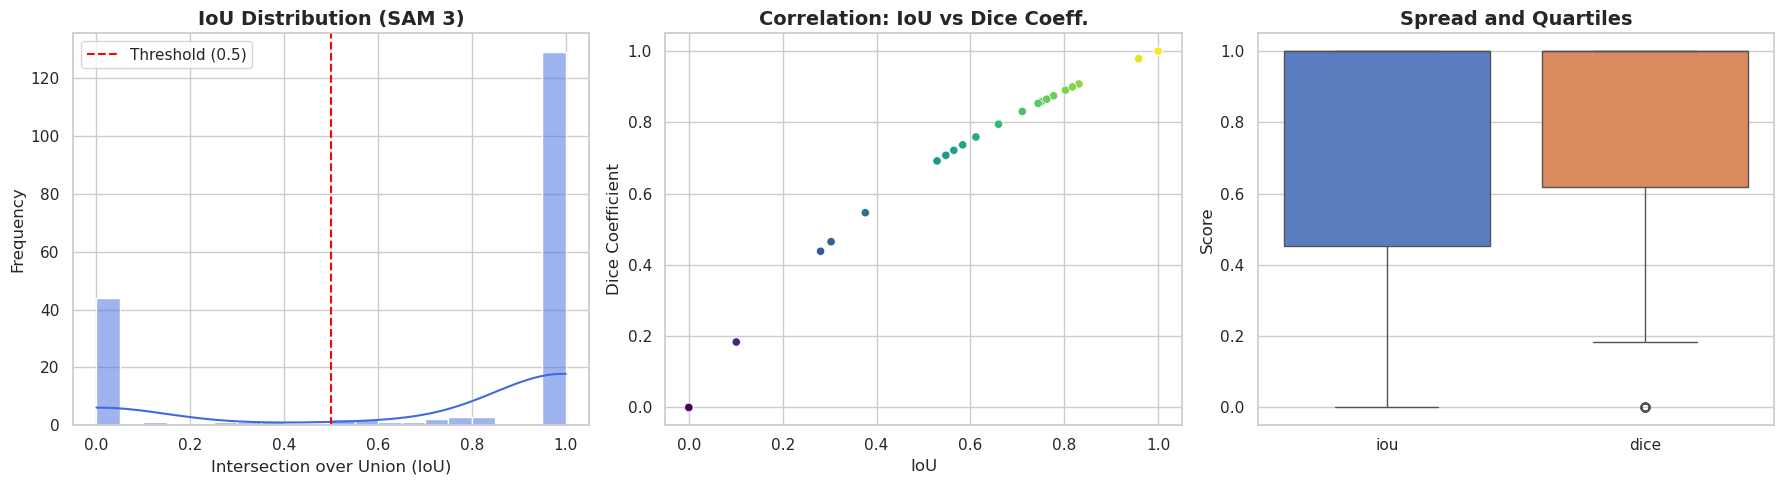

In [9]:
# ==============================================================================
# CELL 8: ADVANCED QUANTITATIVE VISUALIZATION
# ==============================================================================
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. IoU distribution
sns.histplot(df["iou"], bins=20, kde=True, color="royalblue", ax=axs[0])
axs[0].axvline(0.5, color="red", linestyle="--", label="Threshold (0.5)")
axs[0].set_title("IoU Distribution (SAM 3)", fontsize=14, weight="bold")
axs[0].set_xlabel("Intersection over Union (IoU)")
axs[0].set_ylabel("Frequency")
axs[0].legend()

# 2. IoU vs Dice correlation
sns.scatterplot(data=df, x="iou", y="dice", hue="iou", palette="viridis", legend=False, ax=axs[1])
axs[1].set_title("Correlation: IoU vs Dice Coeff.", fontsize=14, weight="bold")
axs[1].set_xlabel("IoU")
axs[1].set_ylabel("Dice Coefficient")

# 3. Metrics boxplot
sns.boxplot(data=df[["iou", "dice"]], palette="muted", ax=axs[2])
axs[2].set_title("Spread and Quartiles", fontsize=14, weight="bold")
axs[2].set_ylabel("Score")

plt.tight_layout()
plt.savefig("sam3_quantitative_analysis.png", dpi=300)
plt.show()


## 8 · Qualitative visualization (best and worst cases)

Finally, we render the top-3 and bottom-3 cases by IoU, overlaying the ground-truth mask (green), the SAM 3 predicted mask (red), and the YOLO26 box prompts (yellow), as a visual sanity check of the segmentation behaviour.


🌟 Generating qualitative visualization (top 3)


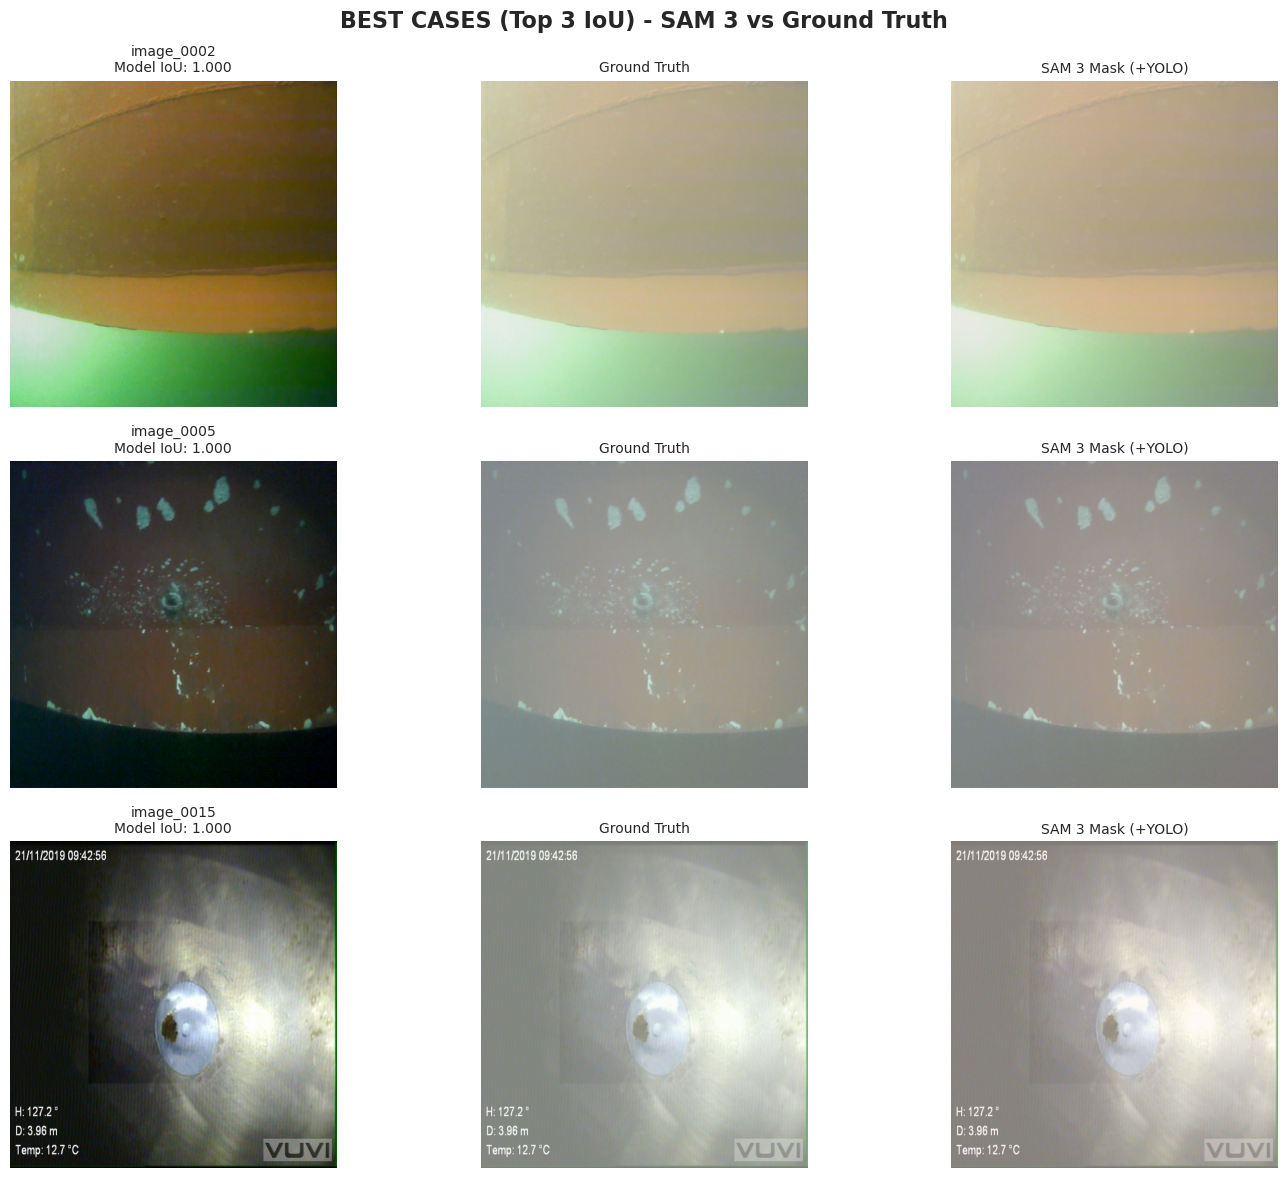


⚠️ Generating qualitative visualization (worst 3)


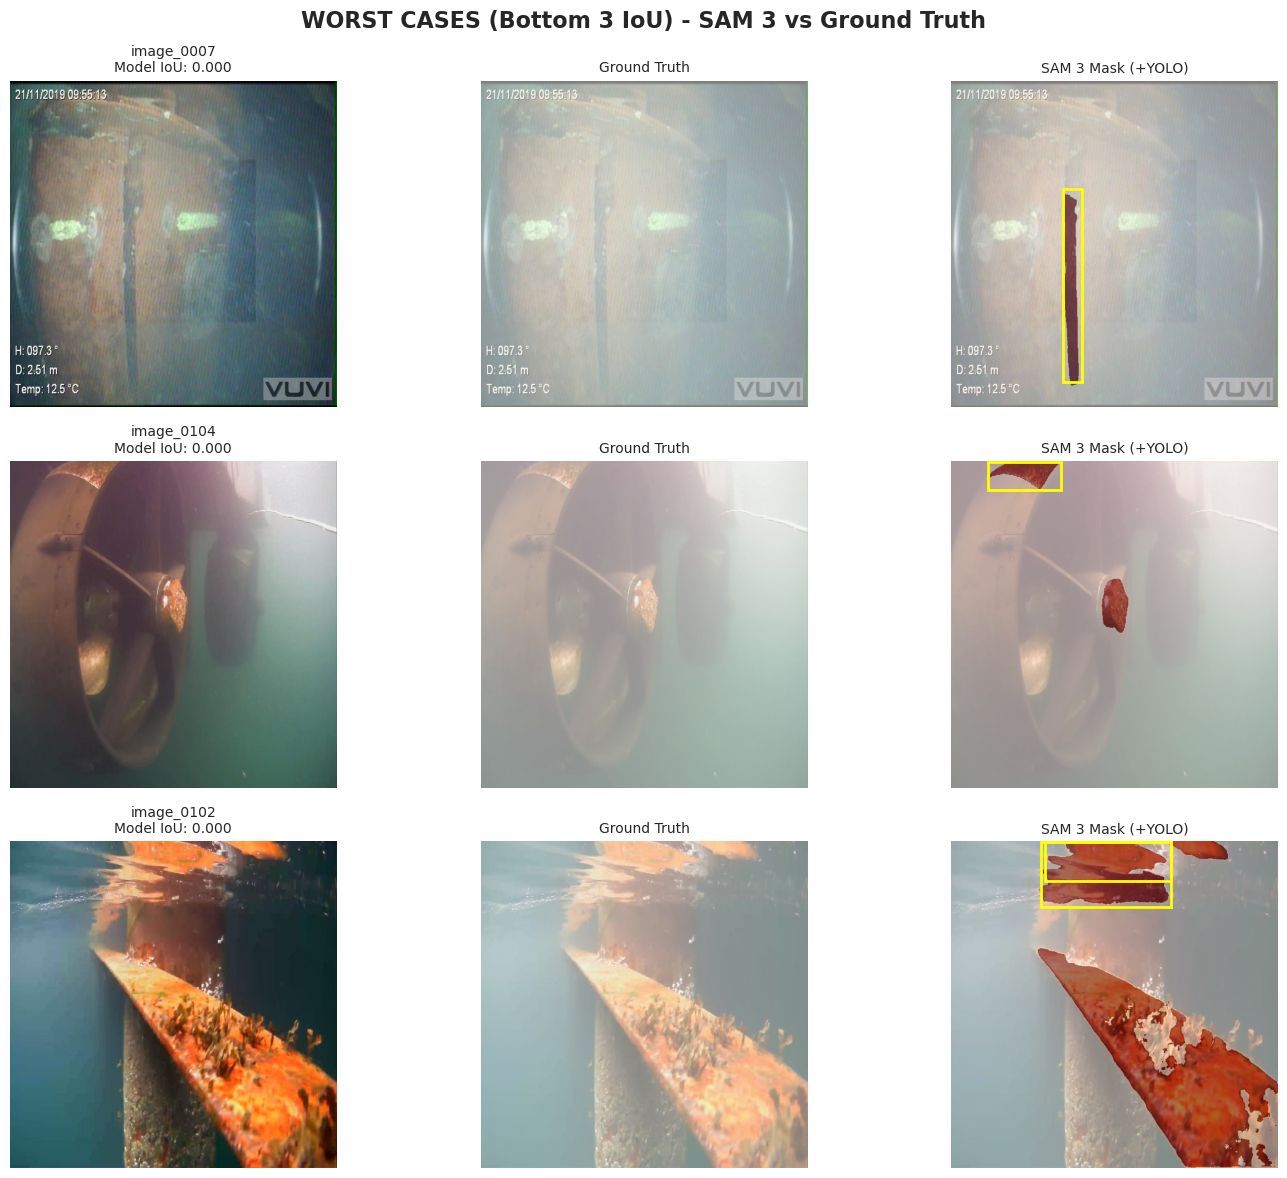

In [10]:
# ==============================================================================
# CELL 9: QUALITATIVE VISUALIZATION (BEST AND WORST CASES)
# ==============================================================================
def plot_qualitative_examples(df_p, sort_asc=False, n=3, title_prefix=""):
    sorted_df = df_p.sort_values(by="iou", ascending=sort_asc).head(n)
    fig, axs = plt.subplots(n, 3, figsize=(15, 4*n))
    for i, (_, row) in enumerate(sorted_df.iterrows()):
        img_name = row["file"]
        iou_score = row["iou"]
        img_path = EVAL_IMGS_DIR / f"{img_name}.jpg"
        if not img_path.exists(): img_path = EVAL_IMGS_DIR / f"{img_name}.png"
        gt_path = EVAL_MASKS_DIR / f"{img_name}.png"
        if not img_path.exists() or not gt_path.exists(): continue
        img = Image.open(img_path).convert("RGB")
        gt_arr = np.array(Image.open(gt_path).convert("L")) > 128
        boxes, masks = detect_and_segment(img, yolo_model, sam_model, sam_processor, DEVICE, YOLO_CONF)
        pred_mask = np.logical_or.reduce(masks) if len(masks) > 0 else np.zeros_like(gt_arr)
        axs[i, 0].imshow(img); axs[i, 0].set_title(f"{img_name}\nModel IoU: {iou_score:.3f}", fontsize=10); axs[i, 0].axis("off")
        axs[i, 1].imshow(img); axs[i, 1].imshow(gt_arr, alpha=0.5, cmap="Greens"); axs[i, 1].set_title("Ground Truth", fontsize=10); axs[i, 1].axis("off")
        axs[i, 2].imshow(img); axs[i, 2].imshow(pred_mask, alpha=0.5, cmap="Reds")
        for box in boxes:
            x0, y0, x1, y1 = box
            rect = plt.Rectangle((x0,y0), x1-x0, y1-y0, fill=False, edgecolor="yellow", linewidth=2)
            axs[i, 2].add_patch(rect)
        axs[i, 2].set_title("SAM 3 Mask (+YOLO)", fontsize=10); axs[i, 2].axis("off")
    fig.suptitle(f"{title_prefix} - SAM 3 vs Ground Truth", fontsize=16, weight="bold")
    plt.tight_layout(); plt.show()

print("\n🌟 Generating qualitative visualization (top 3)")
plot_qualitative_examples(df, sort_asc=False, n=3, title_prefix="BEST CASES (Top 3 IoU)")
print("\n⚠️ Generating qualitative visualization (worst 3)")
plot_qualitative_examples(df, sort_asc=True, n=3, title_prefix="WORST CASES (Bottom 3 IoU)")
